# Task 2: Clustering

In [1]:
from scmlcourse import preprocessing
from pathlib import Path
import scanpy as sc

/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
data_dir = Path("../../data").resolve()
adata = sc.read_h5ad(data_dir/"qced_data.h5ad")
adata

AnnData object with n_obs × n_vars = 212679 × 14097
    obs: 'library_preparation_protocol', 'condition', 'MOI', 'sgRNA', 'UMI_count', 'NO_SITE', 'ONE_NON-GENE_SITE', 'perturbation', 'perturbation_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: None (.X)

/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/preprocessing/_pca.py:206: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")


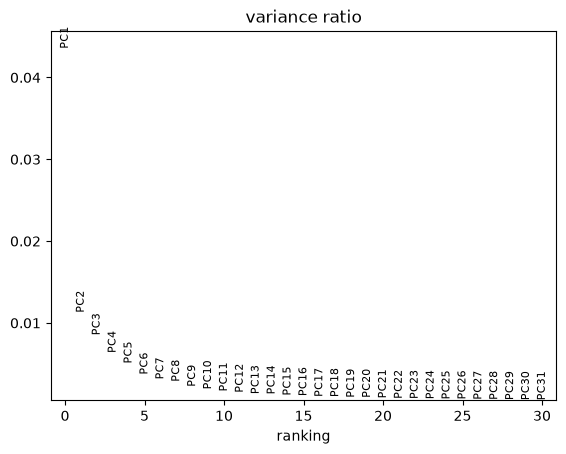

In [3]:
sc.pp.pca(adata)
sc.pl.pca_variance_ratio(adata)

/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1196: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


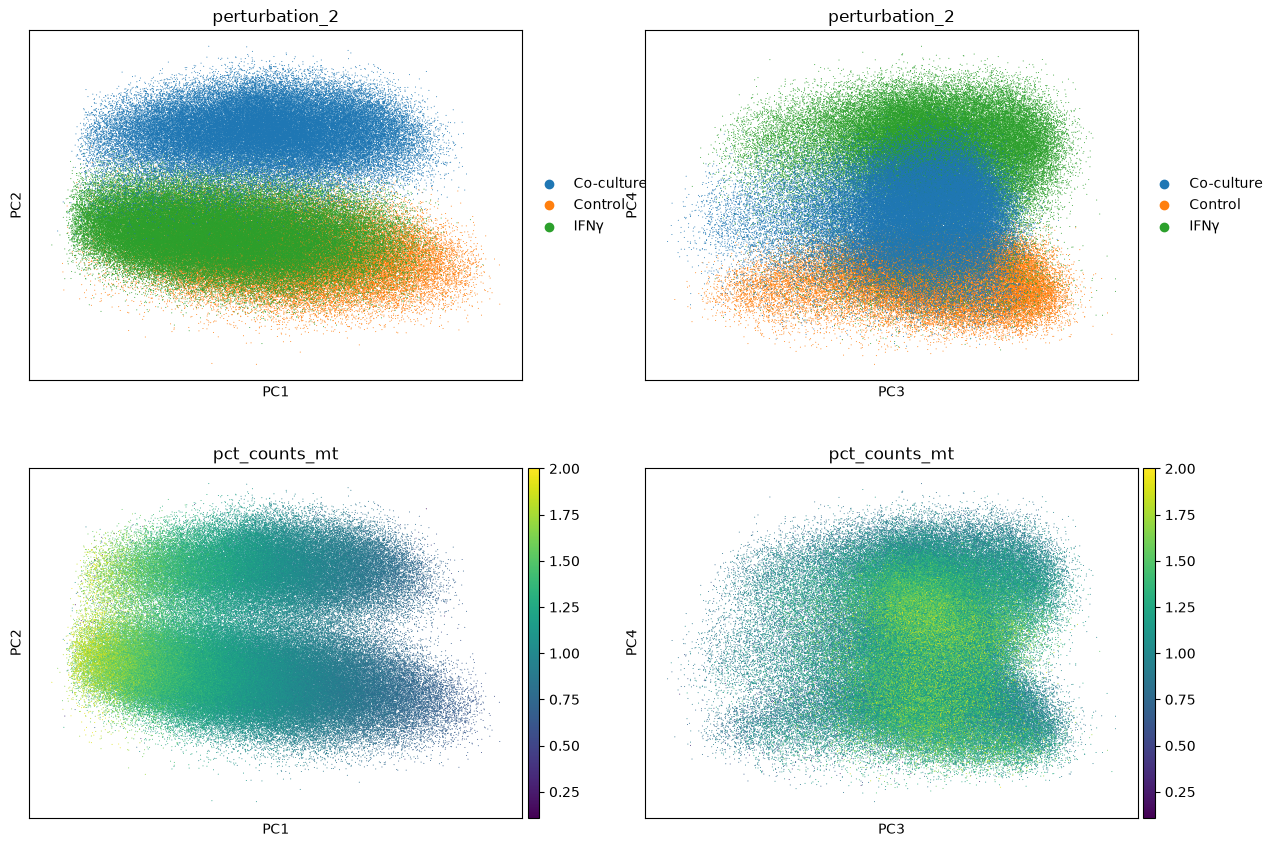

In [4]:
sc.pl.pca(
    adata,
    color=["perturbation_2","perturbation_2", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [5]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=10)
sc.tl.umap(adata)

/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:423: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():
/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1196: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


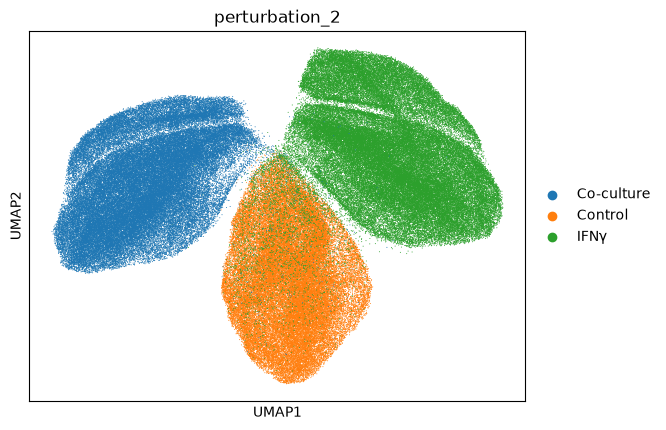

In [6]:
sc.pl.umap(
    adata,
    color="perturbation_2",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

In [ ]:
for res in [0.2, 0.3, 0.4, 0.5, 1]:
    sc.tl.leiden(adata, flavor="igraph", resolution=res, key_added=f"leiden_{res}")

/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1196: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


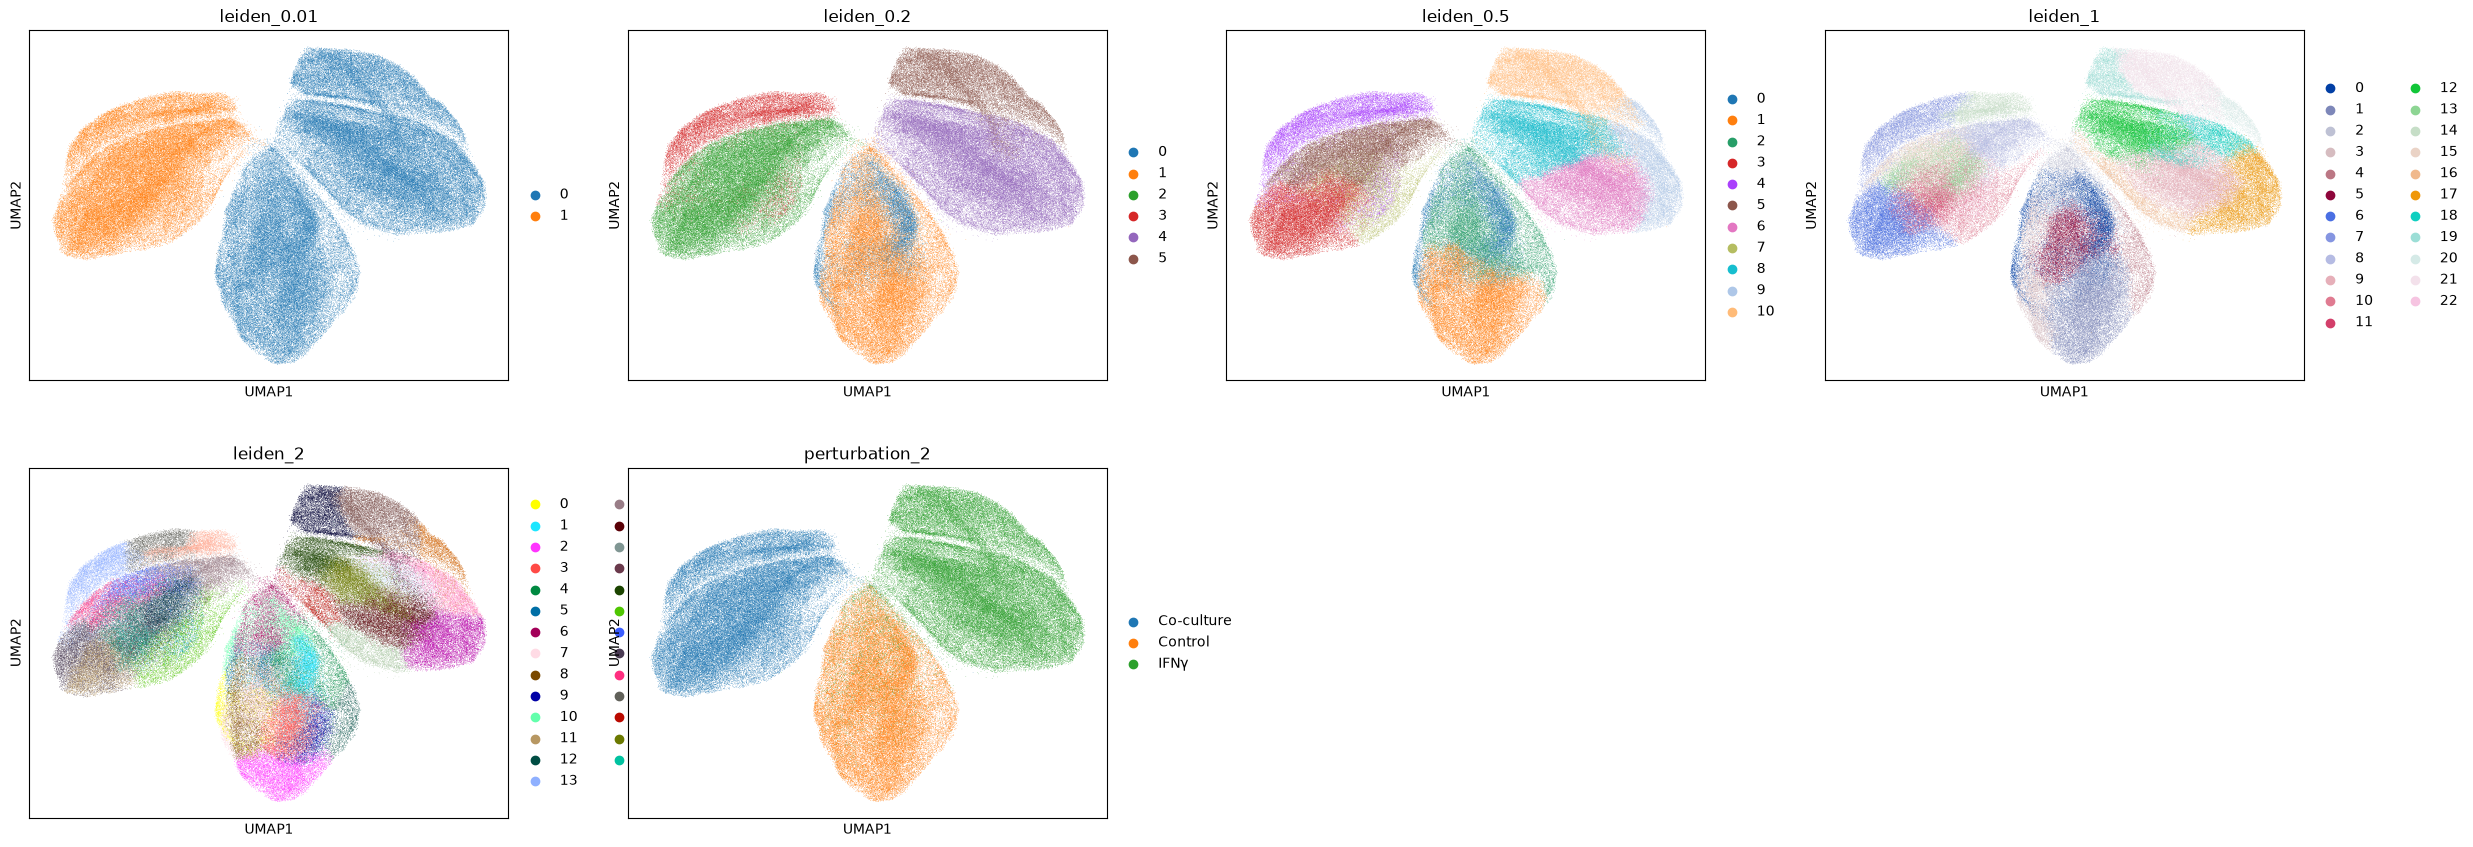

In [ ]:
sc.pl.umap(
    adata,
    color=[f"leiden_{res}" for res in [0.01,0.2, 0.5, 1, 2]]+["perturbation_2"]
)

In [13]:
from sklearn.cluster import KMeans

In [47]:
for n_clusters in range(2, 5):
    kmeans = KMeans(n_clusters=n_clusters)
    adata.obs[f"kmeans_{n_clusters}"] = kmeans.fit_predict(adata.obsm["X_pca"][:,1:])


/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1196: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


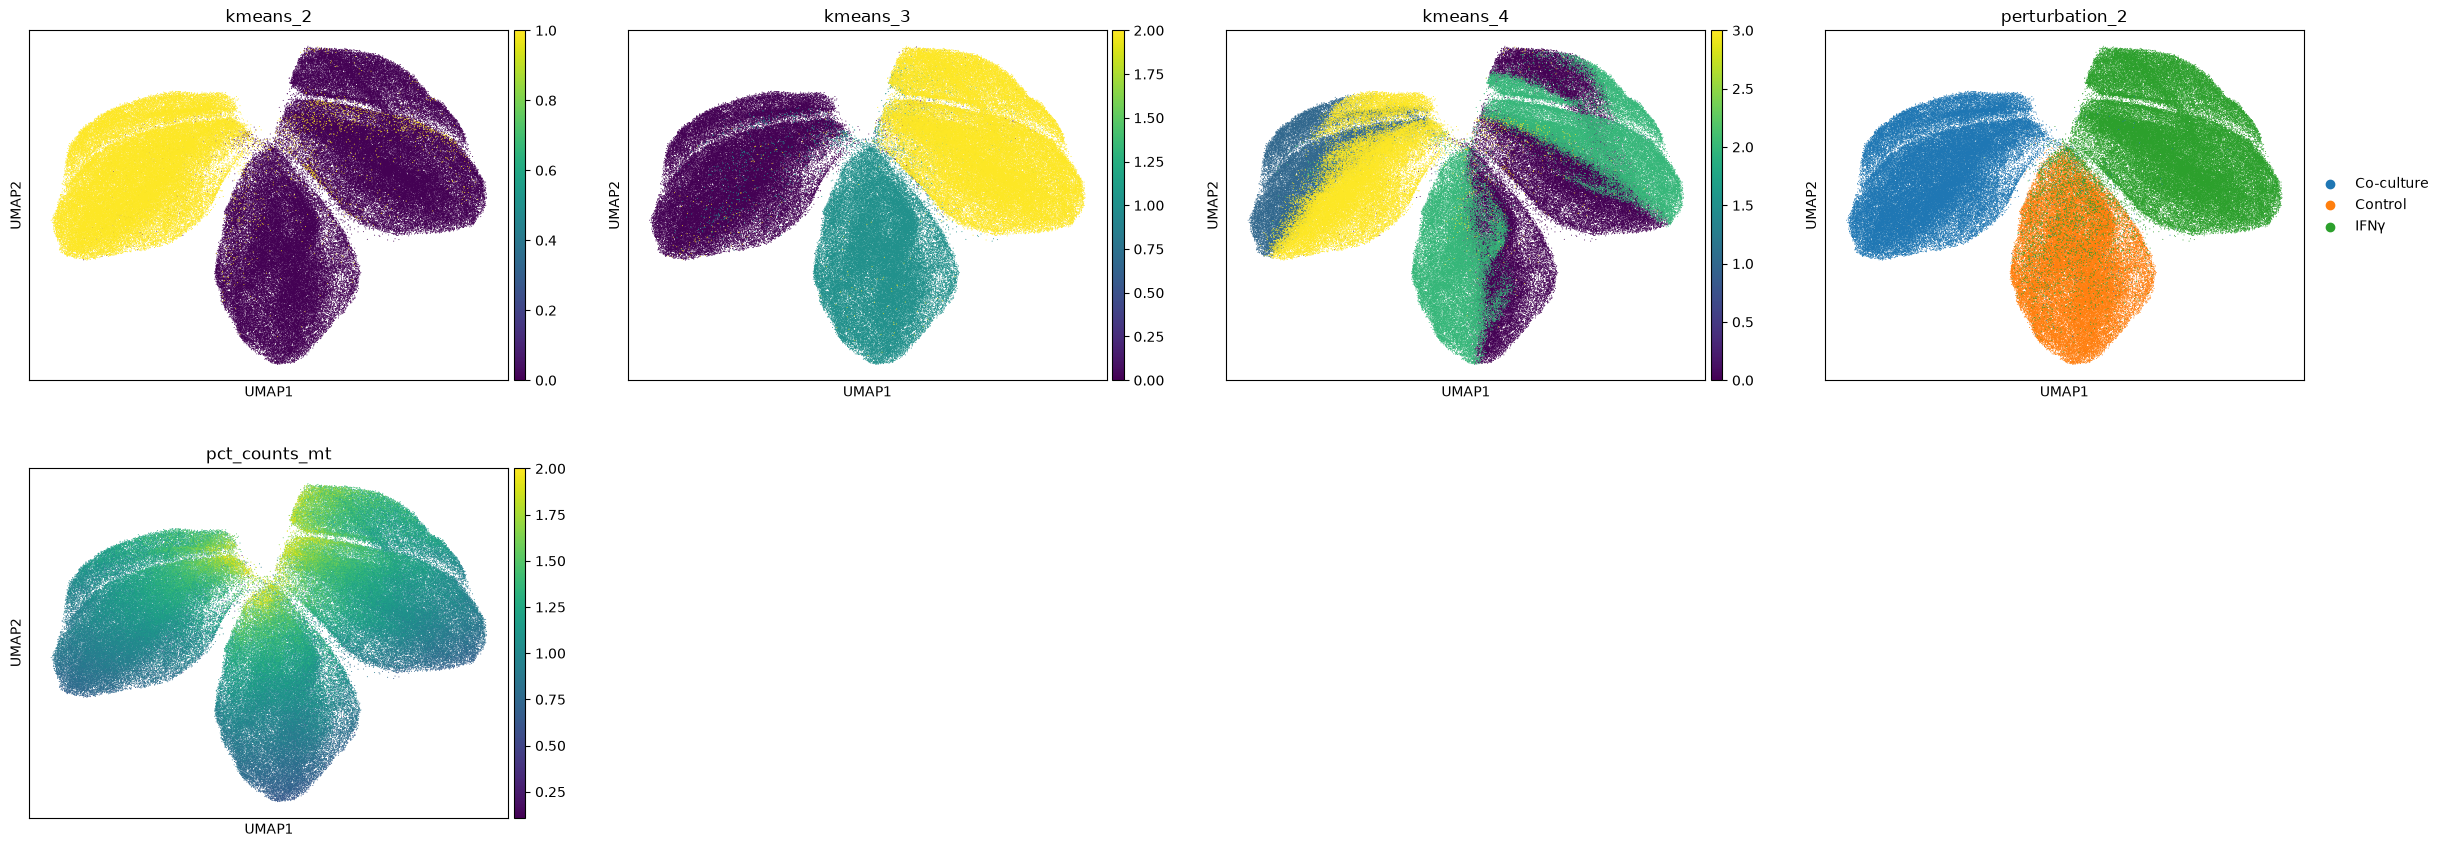

In [48]:
sc.pl.umap(
    adata,
    color=[f"kmeans_{n_clusters}" for n_clusters in range(2, 5)]+["perturbation_2", "pct_counts_mt"],
    size=2
)

In [49]:
adata.write_h5ad(data_dir/"clustered_data.h5ad")